<h1>Train — DenseNet-121</h1>

Trains and evaluates DenseNet-121 using the tuned hyperparameters from `ARCH_HYPERPARAMS["densenet121"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Fisantekraal
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1814 | Val: 441 | Test: 252


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["densenet121"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"DenseNet-121: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

DenseNet-121: micro batch = 16, accumulation steps = 2 (effective batch size ≈ 32, tuned value = 32)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with DenseNet-121)
# ---------------------------------------------------------
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
in_f = model.classifier.in_features
model.classifier = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[DenseNet-121] Using gradient accumulation: 2 micro-batches per optimizer step (effective batch size ≈ micro_batch x 2).


[DenseNet-121] Epoch   1/100 | LR: 1.00e-04 | train loss 1.0062 acc 0.558 | val loss 0.6185 acc 0.726 *


[DenseNet-121] Epoch   2/100 | LR: 1.00e-04 | train loss 0.5924 acc 0.738 | val loss 0.5281 acc 0.773 *


[DenseNet-121] Epoch   3/100 | LR: 1.00e-04 | train loss 0.4724 acc 0.789 | val loss 0.4273 acc 0.832 *


[DenseNet-121] Epoch   4/100 | LR: 1.00e-04 | train loss 0.3995 acc 0.820 | val loss 0.4132 acc 0.825 *


...

[DenseNet-121] Epoch  18/100 | LR: 1.00e-05 | train loss 0.0722 acc 0.968 | val loss 0.4152 acc 0.884


[DenseNet-121] Epoch  19/100 | LR: 1.00e-05 | train loss 0.0568 acc 0.976 | val loss 0.3992 acc 0.893


[DenseNet-121] Epoch  20/100 | LR: 1.00e-05 | train loss 0.0463 acc 0.981 | val loss 0.3998 acc 0.889


[DenseNet-121] Epoch  21/100 | LR: 1.00e-05 | train loss 0.0499 acc 0.976 | val loss 0.4146 acc 0.884


[DenseNet-121] Epoch  22/100 | LR: 1.00e-05 | train loss 0.0618 acc 0.970 | val loss 0.4153 acc 0.893

[DenseNet-121] No val loss improvement for 10 epochs — stopping early at epoch 22.

[DenseNet-121] Restored best checkpoint (val loss = 0.3145)


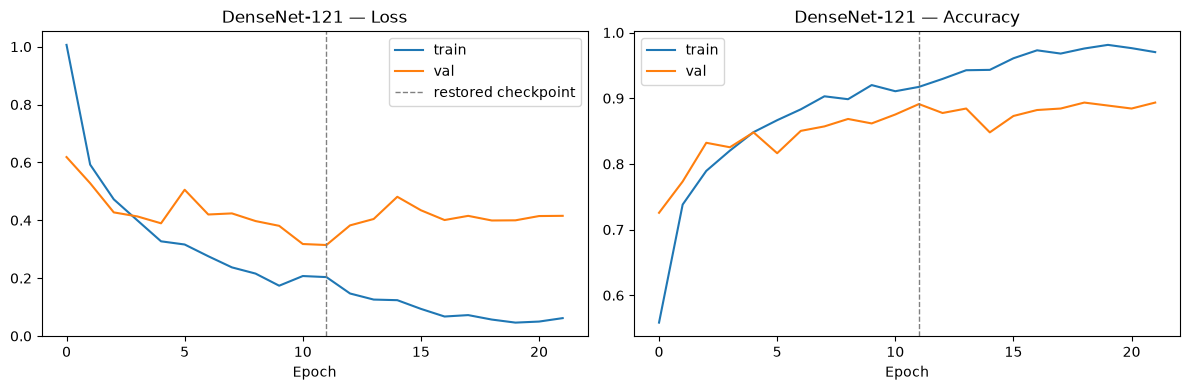

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "DenseNet-121", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "DenseNet-121")

## Evaluate on the test set

[DenseNet-121] Test accuracy: 0.746


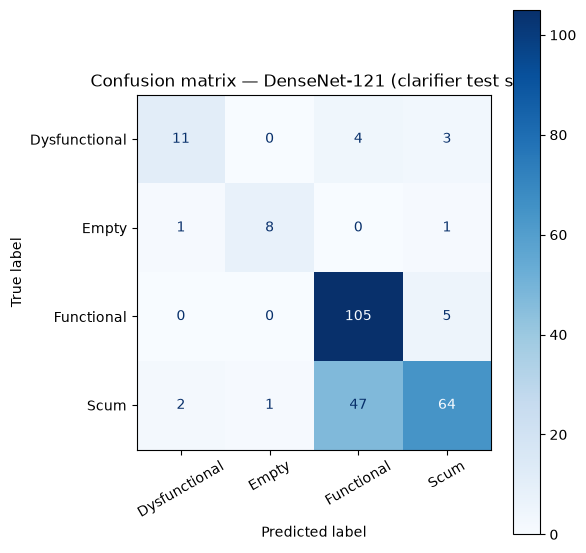

               precision    recall  f1-score   support

Dysfunctional      0.786     0.611     0.688        18
        Empty      0.889     0.800     0.842        10
   Functional      0.673     0.955     0.789       110
         Scum      0.877     0.561     0.684       114

     accuracy                          0.746       252
    macro avg      0.806     0.732     0.751       252
 weighted avg      0.782     0.746     0.737       252



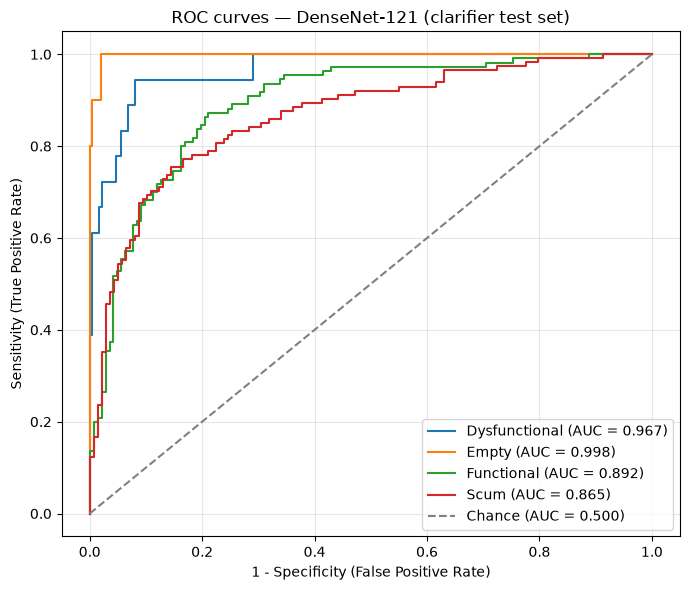

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.967
  Empty          : 0.998
  Functional     : 0.892
  Scum           : 0.865

Mean AUC (over 4/4 classes with test examples): 0.930


(np.float64(0.746031746031746),
 {'Dysfunctional': 0.9667616334283,
  'Empty': 0.9975206611570248,
  'Functional': 0.8923175416133163,
  'Scum': 0.8653699466056444})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "DenseNet-121", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("DenseNet-121", "densenet121")

Saved results to ../results/results_clarifier_densenet121_Fisantekraal.pkl
Saved model weights to ../models/clarifier_densenet121_cnn.pt
